In [1]:
%pylab nbagg
%matplotlib inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon, pearsonr
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Define metrics of interest (5 MOIs)
METRICS_NAMES = [
    'zero_crossing_rate',
    'salience',
    'phase_coherence_matrix_mean_mat',
    'dynamic_functional_connectivity_matrix_var_mat',
    'Entropy_FC'
]

METRICS_5_LABELS = [
    'ZCR',
    'Salience',
    'Entrainment',
    'Fluidity',
    'Complexity'
]

METRIC_LABEL_MAP = dict(zip(METRICS_NAMES, METRICS_5_LABELS))

# Set up data paths
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

# Load HD-EEG data
csv_path_hdeeg = project_root / 'data' / 'df_results' / 'hd-eeg_metrics' / 'df_9MOIs_hd-eeg.csv'
print(f'Loading HD-EEG data from: {csv_path_hdeeg}')
df_hdeeg = pd.read_csv(csv_path_hdeeg)

# Filter for the 5 metrics and rename columns for consistency
df_hdeeg = df_hdeeg[df_hdeeg['metric_name'].isin(METRICS_NAMES)].copy()
df_hdeeg = df_hdeeg.rename(columns={
    'sub': 'participant',
    'run_is': 'session',
    'trial_id': 'trial',
    'metric_name': 'metric',
    'metric_value_pre': 'pre_value',
    'metric_value_post': 'post_value'
})

# Filter for consistent spatial window (radius_pre and radius_post = 100 mm as in Figure_2)
df_hdeeg = df_hdeeg[(df_hdeeg['radius_pre'] == 100) & (df_hdeeg['radius_post'] == 100)].copy()

print(f'✓ HD-EEG data shape: {df_hdeeg.shape}')
print(f'  Unique metrics: {df_hdeeg["metric"].nunique()}')
print(f'  Unique participants: {df_hdeeg["participant"].nunique()}')
print(f'  Unique sessions: {df_hdeeg["session"].nunique()}')

Loading HD-EEG data from: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/hd-eeg_metrics/df_9MOIs_hd-eeg.csv
✓ HD-EEG data shape: (49785, 8)
  Unique metrics: 5
  Unique participants: 36
  Unique sessions: 17


In [4]:
red_color = plt.cm.Blues(0.6)

# Explore data
print(df_hdeeg.head(10))

      participant  radius_pre  radius_post session  trial  \
70560      sub-01         100          100  run-01      0   
70561      sub-01         100          100  run-01      0   
70562      sub-01         100          100  run-01      0   
70563      sub-01         100          100  run-01      0   
70564      sub-01         100          100  run-01      0   
70569      sub-01         100          100  run-01      1   
70570      sub-01         100          100  run-01      1   
70571      sub-01         100          100  run-01      1   
70572      sub-01         100          100  run-01      1   
70573      sub-01         100          100  run-01      1   

                                               metric  pre_value  post_value  
70560                                        salience   0.730268    0.803724  
70561  dynamic_functional_connectivity_matrix_var_mat   0.065701    0.079525  
70562                              zero_crossing_rate   0.024939    0.017570  
70563       

# Variability Analysis (STD)

In [5]:
# STEP 1: Compute variability (STD) across trials for each metric
df_variability_std = (
    df_hdeeg
    .groupby(["participant", "session", "metric"])
    .agg(
        STD_pre=("pre_value", "std"),
        STD_post=("post_value", "std")
    )
    .reset_index()
)

print(f'✓ Computed variability for {len(df_variability_std)} metric×subject×session combinations')
print(df_variability_std.head())

✓ Computed variability for 1590 metric×subject×session combinations
  participant session                                          metric  \
0      sub-01  run-01                                      Entropy_FC   
1      sub-01  run-01  dynamic_functional_connectivity_matrix_var_mat   
2      sub-01  run-01                 phase_coherence_matrix_mean_mat   
3      sub-01  run-01                                        salience   
4      sub-01  run-01                              zero_crossing_rate   

    STD_pre  STD_post  
0  0.215548  0.168854  
1  0.011421  0.008930  
2  0.123514  0.053623  
3  0.243437  0.174957  
4  0.003486  0.002234  


In [6]:
# Test: Pre vs Post STD for each metric
results = []
for metric, df_m in df_variability_std.groupby("metric"):
    diffs = df_m["STD_post"] - df_m["STD_pre"]

    # Non-parametric paired test
    stat_w, p_w = wilcoxon(df_m["STD_post"], df_m["STD_pre"])

    results.append({
        "metric": metric,
        "metric_label": METRIC_LABEL_MAP.get(metric, metric),
        "mean_pre": df_m["STD_pre"].mean(),
        "mean_post": df_m["STD_post"].mean(),
        "mean_diff": diffs.mean(),
        "wilcoxon_stat": stat_w,
        "wilcoxon_p": p_w,
        "n_pairs": len(df_m)
    })

df_stats = pd.DataFrame(results)
print('\n' + '='*80)
print('PRE vs POST STD COMPARISON (Wilcoxon Paired Test)')
print('='*80)
print(df_stats[['metric_label', 'mean_pre', 'mean_post', 'mean_diff', 'wilcoxon_p', 'n_pairs']])


PRE vs POST STD COMPARISON (Wilcoxon Paired Test)
  metric_label  mean_pre  mean_post  mean_diff    wilcoxon_p  n_pairs
0   Complexity  0.167904   0.138373  -0.029531  6.556240e-30      318
1     Fluidity  0.008519   0.009225   0.000707  1.031503e-06      318
2  Entrainment  0.069627   0.046597  -0.023030  6.562689e-48      318
3     Salience  0.174046   0.150864  -0.023182  2.460547e-16      318
4          ZCR  0.003887   0.002681  -0.001206  8.769178e-49      318


In [7]:
# STEP 2: Conditioning analysis (Q1 vs Random) with STD
# Build matrices for each pre/post metric pair
ordered_metrics = METRICS_NAMES
ordered_titles = METRICS_5_LABELS

# Matrix of mean Δ% spread (Q1 - Random) for each pre/post pair
mat = np.zeros((len(ordered_metrics), len(ordered_metrics)))

for i, pre_metric in enumerate(ordered_metrics):
    for j, post_metric in enumerate(ordered_metrics):
        results_pair = []
        
        for (participant, session), df_group in df_hdeeg.groupby(["participant", "session"]):
            # Extract relevant trials
            pre_vals = df_group[df_group["metric"] == pre_metric][["trial", "pre_value"]]
            post_vals = df_group[df_group["metric"] == post_metric][["trial", "post_value"]]

            merged = pd.merge(pre_vals, post_vals, on="trial", suffixes=("_pre", "_post"))
            if merged.empty:
                continue

            # Full STD
            std_full = merged["post_value"].std()
            if std_full == 0 or np.isnan(std_full):
                continue

            # Q1 subset (bottom quartile of pre-metric)
            q1_thr = merged["pre_value"].quantile(0.25)
            subset_q1 = merged[merged["pre_value"] <= q1_thr]
            if len(subset_q1) <= 1:
                continue
            std_q1 = subset_q1["post_value"].std()

            # Random subset (same size as Q1)
            rand_subset = merged.sample(n=len(subset_q1), random_state=0)
            std_rand = rand_subset["post_value"].std()

            # Normalize to full
            rel_q1 = std_q1 / std_full * 100
            rel_rand = std_rand / std_full * 100

            results_pair.append(rel_q1 - rel_rand)

        # Mean Δ% across subjects/sessions
        mat[i, j] = np.nanmean(results_pair) if len(results_pair) > 0 else np.nan

print(f'✓ Computed conditioning matrix (Q1 vs Random) for {ordered_metrics}')

✓ Computed conditioning matrix (Q1 vs Random) for ['zero_crossing_rate', 'salience', 'phase_coherence_matrix_mean_mat', 'dynamic_functional_connectivity_matrix_var_mat', 'Entropy_FC']


# Visualizations

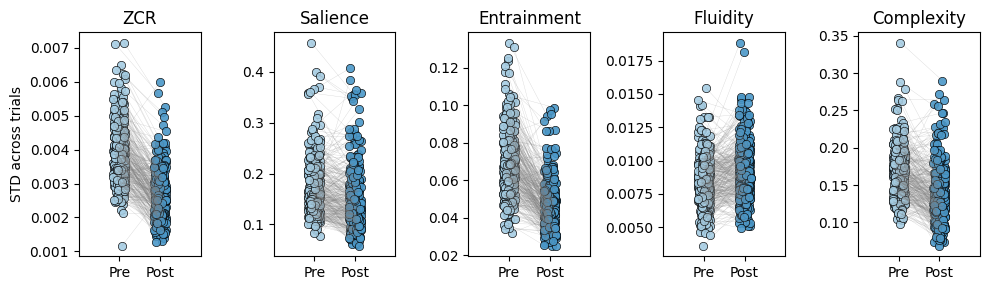

✓ Pre vs Post STD plot saved


In [8]:
# Figure 1: Pre vs Post STD per metric
colors = [plt.cm.Blues(0.35), plt.cm.Blues(0.6)]

fig, axes = plt.subplots(1, len(ordered_metrics), figsize=(10, 3), sharey=False)

for ax, metric, title in zip(axes, ordered_metrics, ordered_titles):
    subset = df_variability_std[df_variability_std["metric"] == metric]

    # Random jitter
    x_pre = 0.9 + np.random.uniform(-0.03, 0.03, size=len(subset))
    x_post = 1.1 + np.random.uniform(-0.03, 0.03, size=len(subset))

    # Dots with thin black rims
    ax.scatter(x_pre, subset["STD_pre"], color=colors[0],
               edgecolor="black", linewidth=0.5, alpha=0.9)
    ax.scatter(x_post, subset["STD_post"], color=colors[1],
               edgecolor="black", linewidth=0.5, alpha=0.9)

    # Connect pairs
    for xp, yp, xq, yq in zip(x_pre, subset["STD_pre"], x_post, subset["STD_post"]):
        ax.plot([xp, xq], [yp, yq], color="gray", linewidth=0.25, alpha=0.35)

    ax.set_xticks([0.9, 1.1])
    ax.set_xticklabels(["Pre", "Post"])
    ax.set_title(title)
    ax.set_xlim(0.7, 1.3)
    
    if metric == ordered_metrics[0]:
        ax.set_ylabel("STD across trials")

plt.tight_layout()
plt.savefig('../results/figures/Figure_3_hdEEG_PrePost_STD.png', dpi=300, bbox_inches='tight',transparent=True)
plt.show()

print('✓ Pre vs Post STD plot saved')


Wilcoxon test (DeltaPerc vs 0): stat=17456.00, p=0.0000


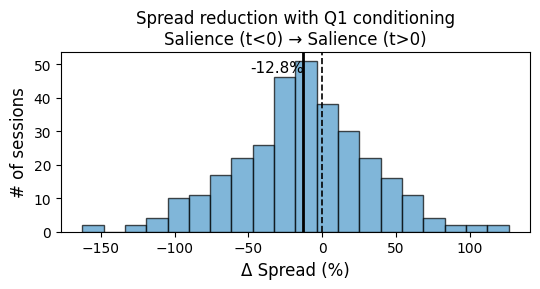

✓ Spread distribution plot saved
  Mean Δ%: -12.8%
  N sessions: 318


In [10]:
# STEP 3: Compute spread statistics for salience→salience (main diagonal)
pre_metric = METRICS_NAMES[1]  # salience
post_metric = METRICS_NAMES[1]  # salience

results_spread = []
for (participant, session), df_group in df_hdeeg.groupby(["participant", "session"]):
    pre_vals = df_group[df_group["metric"] == pre_metric][["trial", "pre_value"]]
    post_vals = df_group[df_group["metric"] == post_metric][["trial", "post_value"]]

    merged = pd.merge(pre_vals, post_vals, on="trial", suffixes=("_pre", "_post"))
    if merged.empty:
        continue

    # Full STD
    std_full = merged["post_value"].std()
    if std_full == 0 or np.isnan(std_full):
        continue

    # Q1 subset
    q1_thr = merged["pre_value"].quantile(0.25)
    subset_q1 = merged[merged["pre_value"] <= q1_thr]
    if len(subset_q1) <= 1:
        continue
    std_q1 = subset_q1["post_value"].std()

    # Random subset
    rand_subset = merged.sample(n=len(subset_q1), random_state=0)
    std_rand = rand_subset["post_value"].std()

    rel_q1 = std_q1 / std_full * 100
    rel_rand = std_rand / std_full * 100

    results_spread.append({
        "participant": participant,
        "session": session,
        "RelSpread_Q1": rel_q1,
        "RelSpread_Random": rel_rand,
        "DeltaPerc": rel_q1 - rel_rand
    })

df_spread = pd.DataFrame(results_spread)
vals = df_spread["DeltaPerc"].dropna().values
mean_val = np.mean(vals)

# Wilcoxon test
if len(vals) > 0:
    stat, pval = wilcoxon(vals)
    print(f'\nWilcoxon test (DeltaPerc vs 0): stat={stat:.2f}, p={pval:.4f}')

# Figure 2: Histogram of Δ% spread
fig, ax = plt.subplots(figsize=(5.5, 3))

ax.hist(vals, bins=20, orientation="vertical",
        color=red_color, edgecolor="black", alpha=0.7)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.axvline(mean_val, color="k", linestyle="-", linewidth=2)

ymax = ax.get_ylim()[1]
ax.text(mean_val-18, ymax*0.87, f"{mean_val:.1f}%", 
        ha="center", va="bottom", fontsize=11, color="k")

ax.set_xlabel("Δ Spread (%)", fontsize=12)
ax.set_ylabel("# of sessions", fontsize=12)
ax.set_title("Spread reduction with Q1 conditioning\nSalience (t<0) → Salience (t>0)", fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/Figure_4_hdEEG_Spread_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Spread distribution plot saved')
print(f'  Mean Δ%: {mean_val:.1f}%')
print(f'  N sessions: {len(vals)}')

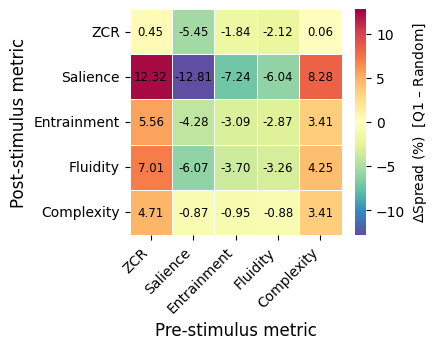

✓ Heatmap saved
  Matrix shape: (5, 5)
  Value range: [-12.81, 12.32]


In [13]:
# Figure 3: Heatmap of Δ% spread matrix
A = np.nanmax(np.abs(mat))  # symmetric color scaling

plt.figure(figsize=(4.4, 3.6))
ax = sns.heatmap(
    mat.T, annot=True, fmt=".2f", annot_kws={"size": 8.5, "color": "black"},
    cmap="Spectral_r", vmin=-A, vmax=A, linewidths=0.5,
    cbar_kws={'label': r'$\Delta \mathrm{Spread}$ (%)  [Q1 – Random]'}
)

ax.set_xticklabels(ordered_titles, rotation=45, ha='right')
ax.set_yticklabels(ordered_titles, rotation=0)

plt.ylabel("Post-stimulus metric", fontsize=12)
plt.xlabel("Pre-stimulus metric", fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/Figure_4_hdEEG_Spread_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Heatmap saved')
print(f'  Matrix shape: {mat.shape}')
print(f'  Value range: [{np.nanmin(mat):.2f}, {np.nanmax(mat):.2f}]')